In [1]:
import sys
from utils import * 


In [2]:
csv_file = "creditcard.csv"
DATASET_NAME = csv_file.replace(".csv", "")
TARGET_COL = "Class"
DROP_COLS = ['Class', 'Time']

df = pd.read_csv(csv_file)
# df

Class
0    284315
1       492
Name: count, dtype: int64


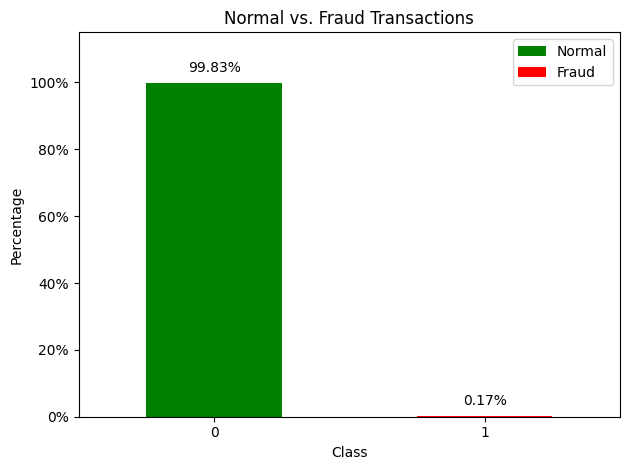

In [3]:
plot_class_distribution(df, target_col=TARGET_COL)


In [4]:
# Data preprocessing
X_train, X_test, y_train, y_test = anomaly_preprocess(df=df, target_col=TARGET_COL, drop_cols=DROP_COLS)


In [5]:
# ------------------ Autoencoder Feature Extraction ------------------
X_train, X_test = apply_autoencoder(X_train, X_test)

print("Encoded train shape:", X_train.shape)
print("Encoded test shape:", X_test.shape)


Epoch 1/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: -0.5719
Epoch 2/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - loss: -3.7643
Epoch 3/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: -6.7006
Epoch 4/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: -9.6412
Epoch 5/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - loss: -12.6044
Epoch 6/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: -15.5472
Epoch 7/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: -18.4873
Epoch 8/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: -21.4226
Epoch 9/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: -24.3946
Epoch 10/10
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: -27.3864
6908/6908 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Encoded train shape: (221028, 8)
Encoded test shape: (56962, 8)


In [6]:
import joblib

joblib.dump((DATASET_NAME, X_train, X_test, y_train, y_test), "ULB_data.pkl")

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("ULB_data.pkl")
